# Figure 6 — Fisher-Rao guidance reduces atomic collapse on a known manifold (sinusoid)

Renders `fig6.{pdf,png}`: 2x5 grid, rows `N=10`/`N=20`, columns unguided / ambient FR /
ambient Bayesian FR / projected FR / projected Bayesian FR, with the Fisher-Rao energy field
and cell boundaries shaded behind the samples.

Cheap (d=2 MLP), regenerates samples each run; `REUSE_CACHE=True` skips sampling. No
hyperparameters drawn in the figure -- the run cell prints them for the caption.

In [1]:
import os, sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

REPO = os.path.abspath("../..")
sys.path.insert(0, os.path.join(REPO, "src"))
sys.path.insert(0, os.path.join(REPO, "workshop_figures"))

from guidance import driver, basic_fr, bayesian_fr
import wsstyle

mpl_fs = 19
wsstyle.use_style(font_size=mpl_fs)

CKPT_DIR = os.path.join(REPO, "experiments", "sinusoid", "checkpoints")
CACHE = os.path.join(REPO, "workshop_figures", "cache", "fig6_samples.pt")
REUSE_CACHE = False

config = {
    "regime": "normal",
    "N_list": [10, 20],
    "n_steps": 1000,
    "n_samples": 200,
    "seed": 10,
    "k_neighbors": 5,
    "ell": 1,
    "eta": 0.5,
    "window": (0.8, 1.0),
    "q_target": 0.9,
    "mem_dist_threshold": 0.05,
    "dirichlet_alpha": 0.1,
    "B_bootstrap": 256,
}
print(config)

{'regime': 'normal', 'N_list': [10, 20], 'n_steps': 1000, 'n_samples': 200, 'seed': 10, 'k_neighbors': 5, 'ell': 1, 'eta': 0.5, 'window': (0.8, 1.0), 'q_target': 0.9, 'mem_dist_threshold': 0.05, 'dirichlet_alpha': 0.1, 'B_bootstrap': 256}


## Score network and per-`N` wiring

In [2]:
class ScoreNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d)

    def forward(self, x, t):
        h = F.silu(self.input_proj(torch.cat([x, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

In [3]:
def build_run(N):
    """One closure per N: two rows use two different score nets sharing a mutable
    timestep holder, so globals would cross-contaminate the rows."""
    ckpt = torch.load(os.path.join(CKPT_DIR, f"score_{config['regime']}_N{N}.pt"), weights_only=False)
    tc = ckpt["config"]
    d, device = tc["d"], tc["device"]
    X_target = ckpt["X_target"].to(device)

    net = ScoreNet(d, tc["hidden"], tc["depth"]).to(device)
    net.load_state_dict(ckpt["net_state"])
    net.eval()

    beta_min, beta_max, T = tc["beta_min"], tc["beta_max"], tc["T"]
    n_steps = config["n_steps"]
    dt = T / n_steps
    t_hold = {"t": None}

    def beta(t):
        return beta_min + t * (beta_max - beta_min)

    def alpha_bar(t):
        return torch.exp(-(beta_min * t + 0.5 * (beta_max - beta_min) * t ** 2))

    def sigma2(t):
        return (1 - alpha_bar(t)).clamp(min=1e-4)

    def base_step_fn(z_t, step_idx):
        k = n_steps - step_idx
        t_vec = torch.full((z_t.shape[0],), (k + 1) * dt, device=device)
        t_hold["t"] = t_vec
        with torch.no_grad():
            eps_hat = net(z_t, t_vec)
            score = -eps_hat / sigma2(t_vec)[:, None].sqrt()
            drift = -0.5 * beta(t_vec)[:, None] * z_t - beta(t_vec)[:, None] * score
            noise = beta(t_vec)[:, None].sqrt() * torch.randn_like(z_t) if k > 0 else 0
        return z_t - drift * dt + noise * dt ** 0.5

    def y_fn(z_t):
        t_vec = t_hold["t"]
        eps_hat = net(z_t, t_vec)
        a = alpha_bar(t_vec)
        return (z_t - (1 - a)[:, None].sqrt() * eps_hat) / a[:, None].sqrt()

    def beta_t_fn():
        return sigma2(t_hold["t"])

    def tangent_projector(y):
        u = y[:, 0].clamp(-3.2, 3.2)
        tv = torch.stack([torch.ones_like(u), 1.2 * torch.cos(2 * u)], dim=-1)
        tv = tv / tv.norm(dim=-1, keepdim=True)
        return torch.einsum("bi,bj->bij", tv, tv)

    def _y_single(z_i, t_i):
        eps_hat = net(z_i[None], t_i[None])
        a = alpha_bar(t_i[None])
        return ((z_i[None] - (1 - a)[:, None].sqrt() * eps_hat) / a[:, None].sqrt())[0]

    _dj = torch.func.vmap(torch.func.jacrev(_y_single))

    def denoiser_jacobian_fn(z_t):
        return _dj(z_t, t_hold["t"]).detach()

    index = basic_fr.build_flat_index(X_target)
    K, qt = config["k_neighbors"], config["q_target"]

    energies = {
        ("ambient", "basic"): basic_fr.make_knn_fr_energy_fn(index, K, beta_t_fn, q_target=qt),
        ("ambient", "bayesian"): bayesian_fr.make_knn_bayesian_fr_energy_fn(
            index, K, beta_t_fn, B=config["B_bootstrap"],
            dirichlet_alpha=config["dirichlet_alpha"], q_target=qt),
        ("projected", "basic"): basic_fr.make_knn_projected_energy_fn(index, K, beta_t_fn, q_target=qt),
        ("projected", "bayesian"): bayesian_fr.make_knn_bayesian_projected_energy_fn(
            index, K, beta_t_fn, B=config["B_bootstrap"],
            dirichlet_alpha=config["dirichlet_alpha"], q_target=qt),
    }

    def make_guidance_fn(space, method):
        e = energies[(space, method)]
        if space == "ambient":
            return driver.make_autograd_guidance_fn(y_fn, e, target_range=None)
        return driver.make_projected_guidance_fn(
            y_fn, e, tangent_projector, target_range=None,
            denoiser_jacobian_fn=denoiser_jacobian_fn)

    def run(space=None, method=None):
        torch.manual_seed(config["seed"])
        z = torch.randn(config["n_samples"], d, device=device)
        if space is None:
            with torch.no_grad():
                for step_idx in range(1, n_steps + 1):
                    z = base_step_fn(z, step_idx)
            return z.detach()
        z_final, _ = driver.guided_reverse_loop(
            z, n_steps, base_step_fn, make_guidance_fn(space, method),
            progress_lo=config["window"][0], progress_hi=config["window"][1],
            ell=config["ell"], trust_region=config["eta"])
        return z_final.detach()

    return {"run": run, "X_target": X_target, "device": device}

## Run every panel

In [4]:
PANELS = [(None, None), ("ambient", "basic"), ("ambient", "bayesian"),
          ("projected", "basic"), ("projected", "bayesian")]

def mem_mask(X, atoms, thresh):
    return torch.cdist(X, atoms).min(dim=1).values < thresh

if REUSE_CACHE and os.path.exists(CACHE):
    payload = torch.load(CACHE, weights_only=False)
    print("loaded cache", CACHE)
else:
    payload = {"config": config, "rows": {}}
    for N in config["N_list"]:
        r = build_run(N)
        cols = []
        for space, method in PANELS:
            X = r["run"](space, method)
            frac = mem_mask(X, r["X_target"], config["mem_dist_threshold"]).float().mean().item()
            cols.append({"space": space, "method": method, "X": X.cpu()})
            print(f"N={N:>3}  {str(space):>9}/{str(method):<8}  memorized={frac:.3f}")
        payload["rows"][N] = {"X_target": r["X_target"].cpu(), "cols": cols}
    torch.save(payload, CACHE)
    print("saved ->", CACHE)

print("\ncaption numbers: "
      f"k={config['k_neighbors']}, eta={config['eta']}, window={config['window']}, "
      f"q_target={config['q_target']}, n_samples={config['n_samples']}, "
      f"steps={config['n_steps']}, seed={config['seed']}, "
      f"Dirichlet alpha={config['dirichlet_alpha']}, B={config['B_bootstrap']}, "
      f"memorized if dist < {config['mem_dist_threshold']}")

N= 10       None/None      memorized=0.840


N= 10    ambient/basic     memorized=0.525


N= 10    ambient/bayesian  memorized=0.140


N= 10  projected/basic     memorized=0.555


N= 10  projected/bayesian  memorized=0.245


N= 20       None/None      memorized=0.505


N= 20    ambient/basic     memorized=0.055


N= 20    ambient/bayesian  memorized=0.025


N= 20  projected/basic     memorized=0.045


N= 20  projected/bayesian  memorized=0.015
saved -> /Users/bengusunar/Downloads/memorization_diffusion_models_code/workshop_figures/cache/fig6_samples.pt

caption numbers: k=5, eta=0.5, window=(0.8, 1.0), q_target=0.9, n_samples=200, steps=1000, seed=10, Dirichlet alpha=0.1, B=256, memorized if dist < 0.05


## Setup for rendering

Manifold curve, panel grid layout, and block/column titles shared by the figure below.

In [5]:
import numpy as np

XLIM = (-3.2, 2.85)
YLIM = (-0.72, 0.72)

u_scan = torch.linspace(-4.0, 4.0, 4000)
curve = torch.stack([u_scan, 0.6 * torch.sin(2 * u_scan)], dim=-1).numpy()

N_list = config["N_list"]
BLOCKS = [("Unguided", [(None, None)]),
          ("Ambient", [("ambient", "basic"), ("ambient", "bayesian")]),
          ("Tangent-projected", [("projected", "basic"), ("projected", "bayesian")])]
COL_TITLES = [None, ["FR", "Bayesian FR"], ["FR", "Bayesian FR"]]
KEYS = [k for _, cells in BLOCKS for k in cells]
Zo = wsstyle.Z

## Render

Fisher-Rao energy field `I(y)` at `t=0.05` (alpha-shaded) and dotted cell boundaries behind
the samples.

These are plain Voronoi cells, not Laguerre: `fisher_rao_energy`'s `beta_t*log N` term is
constant across candidates and cancels in the softmax, and Laguerre reduces to Voronoi when
atoms carry equal weight. `I` peaks on the cell walls (posterior most tied, `Var_q(g)` largest),
so the shading and boundaries coincide by construction -- guidance ascends `I`, walking a sample
off its atom toward the wall.

['/Users/bengusunar/Downloads/memorization_diffusion_models_code/workshop_figures/out/fig6.pdf', '/Users/bengusunar/Downloads/memorization_diffusion_models_code/workshop_figures/out/fig6.png']


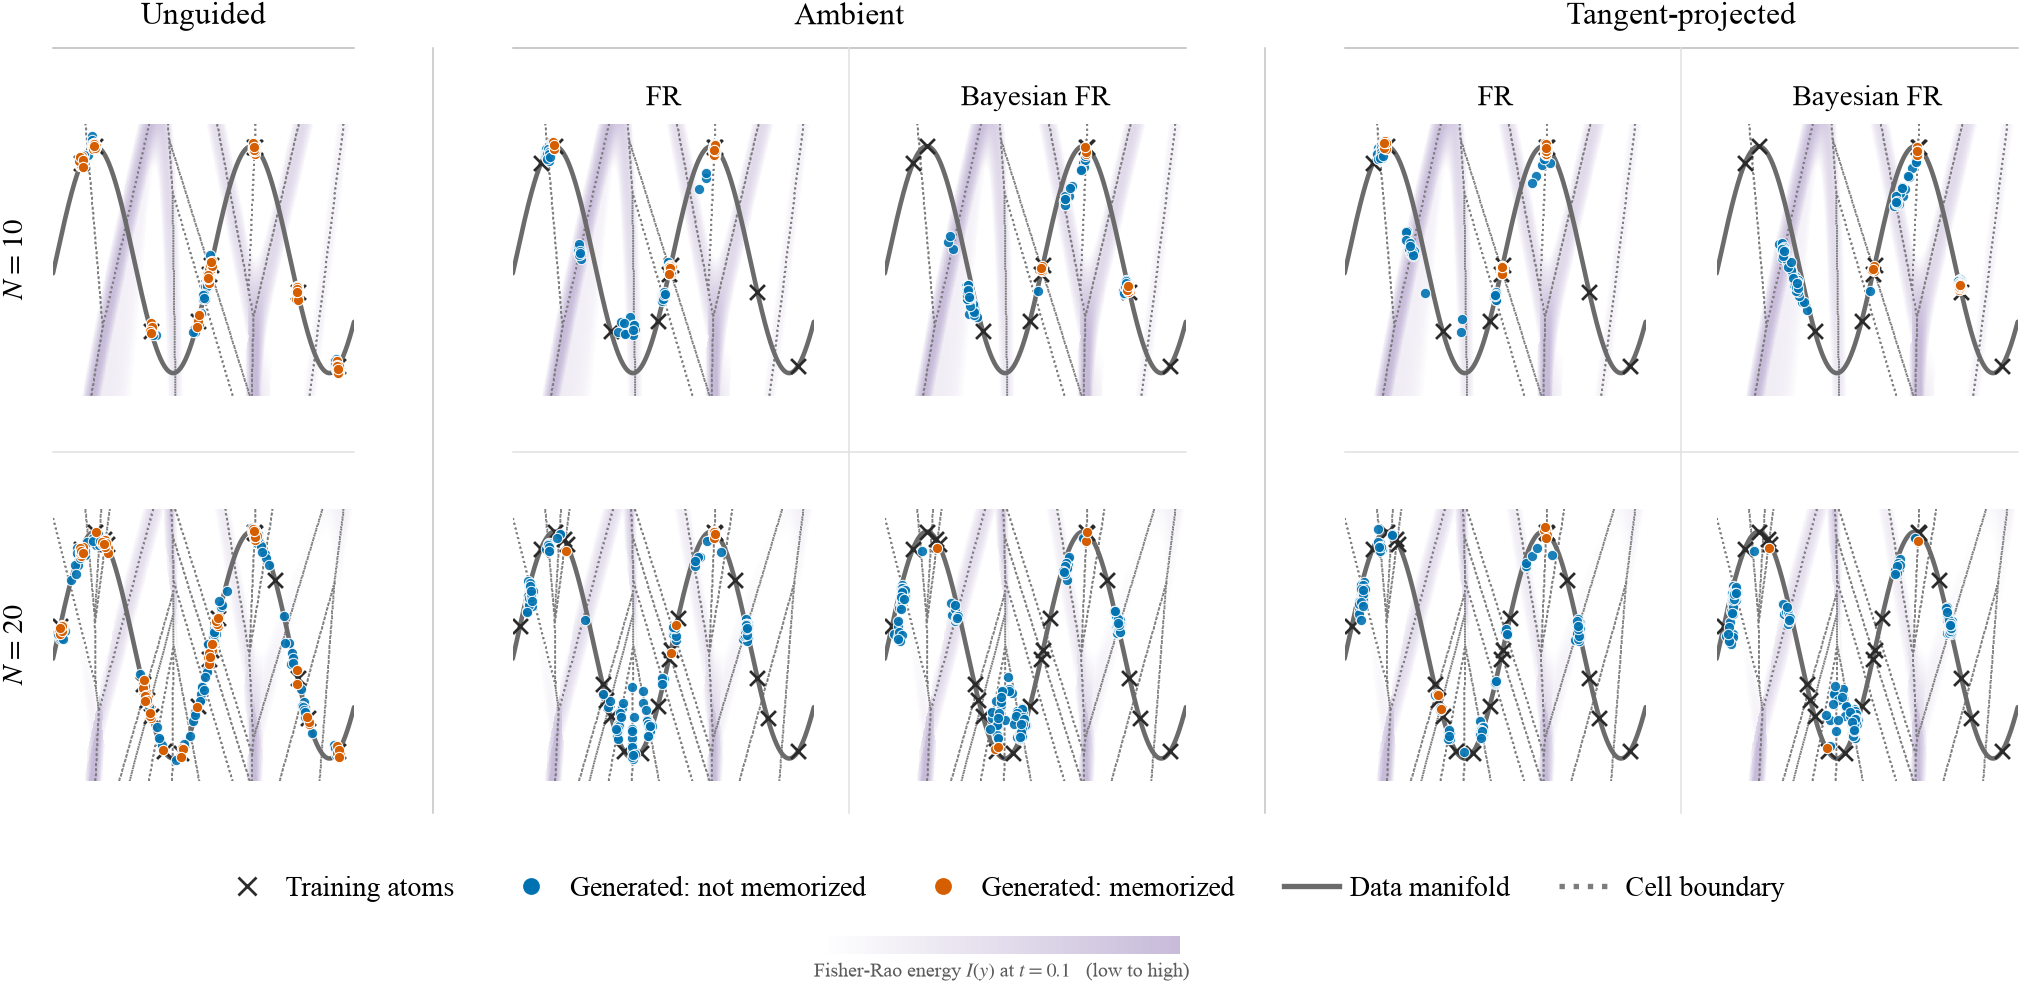

In [6]:
from matplotlib.colors import Normalize

T_FIELD = 0.1
GRID_NX, GRID_NY = 460, 220
BOUND_COLOR = "#7C7C7C"

# Schedule constants live in the training checkpoint, not in the sample cache.
_tc = torch.load(os.path.join(CKPT_DIR, f"score_{config['regime']}_N{N_list[0]}.pt"),
                 weights_only=False)["config"]
BETA_MIN, BETA_MAX = _tc["beta_min"], _tc["beta_max"]

def _sigma2(t):
    ab = torch.exp(-(BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t ** 2))
    return (1 - ab).clamp(min=1e-4)

S2_FIELD = _sigma2(torch.tensor(T_FIELD))

def energy_field(X_target):
    """I(y) and nearest-atom label on a grid; same tempered energy the sampler used."""
    gx = torch.linspace(*XLIM, GRID_NX)
    gy = torch.linspace(*YLIM, GRID_NY)
    GY, GX = torch.meshgrid(gy, gx, indexing="ij")
    pts = torch.stack([GX.reshape(-1), GY.reshape(-1)], dim=-1)

    index = basic_fr.build_flat_index(X_target)
    nbrs, sq_d = basic_fr.ann_query(index, pts, config["k_neighbors"])
    beta_t = S2_FIELD.expand(pts.shape[0])
    beta_soft = basic_fr.beta_soft_for(sq_d, config["q_target"])
    I, _, _ = basic_fr.fisher_rao_energy(pts, nbrs, beta_t, beta_soft=beta_soft)

    label = torch.cdist(pts, X_target).argmin(dim=1)
    return (GX.numpy(), GY.numpy(),
            I.reshape(GRID_NY, GRID_NX).numpy(),
            label.reshape(GRID_NY, GRID_NX).numpy())

fields = {N: energy_field(payload["rows"][N]["X_target"]) for N in N_list}

# shared log10 colour scale (I spans orders of magnitude cell-centre to wall)
_all = np.concatenate([np.log10(f[2].ravel() + 1e-12) for f in fields.values()])
VMIN, VMAX = np.percentile(_all, 72), np.percentile(_all, 99.5)
norm = Normalize(vmin=VMIN, vmax=VMAX)
cmap = wsstyle.alpha_ramp_cmap(wsstyle.C["field"], alpha_max=0.42)

fig = plt.figure(figsize=(19.0, 9.8))
axes, blocks, block_rects = wsstyle.place_grid(
    fig, n_rows=len(N_list), block_sizes=[len(c) for _, c in BLOCKS],
    left=0.046, right=0.014, top=0.815, bottom=0.205,
    block_gap=0.076, panel_gap=0.034, row_gap=0.105,
    equal_block_width=False)

for i, N in enumerate(N_list):
    row = payload["rows"][N]
    atoms = row["X_target"].numpy()
    by = {(c["space"], c["method"]): c for c in row["cols"]}
    GXn, GYn, I_grid, label = fields[N]
    for j, key in enumerate(KEYS):
        ax = axes[i][j]
        X = by[key]["X"]
        m = mem_mask(X, row["X_target"], config["mem_dist_threshold"]).numpy()
        Xn = X.numpy()

        im = ax.pcolormesh(GXn, GYn, np.log10(I_grid + 1e-12), cmap=cmap,
                           norm=norm, shading="auto", zorder=-2, rasterized=True)
        for a in range(atoms.shape[0]):
            ax.contour(GXn, GYn, (label == a).astype(float), levels=[0.5],
                       colors=[BOUND_COLOR], linestyles=":", linewidths=1.25,
                       zorder=-1)

        ax.plot(curve[:, 0], curve[:, 1], color="#6B6B6B",
                lw=wsstyle.MARK["curve_lw"], zorder=Zo["manifold"], solid_capstyle="round")
        ax.scatter(atoms[:, 0], atoms[:, 1], s=wsstyle.MARK["atom_s"],
                   color="#2B2B2B", marker="x",
                   linewidths=wsstyle.MARK["atom_lw"], zorder=Zo["atoms"])
        ax.scatter(Xn[~m, 0], Xn[~m, 1], s=wsstyle.MARK["sample_s"],
                   color=wsstyle.C["unmemorized"], alpha=wsstyle.MARK["sample_alpha"],
                   edgecolors="white", linewidths=wsstyle.MARK["sample_edge"],
                   zorder=Zo["unmemorized"])
        ax.scatter(Xn[m, 0], Xn[m, 1], s=wsstyle.MARK["sample_s"],
                   color=wsstyle.C["memorized"], alpha=1.0,
                   edgecolors="white", linewidths=wsstyle.MARK["sample_edge"],
                   zorder=Zo["memorized"])
        ax.set_xlim(*XLIM)
        ax.set_ylim(*YLIM)
        wsstyle.strip_axes(ax)

for i, N in enumerate(N_list):
    axes[i][0].set_ylabel(rf"$N = {N}$", labelpad=16)
for b, titles in enumerate(COL_TITLES):
    if titles is None:
        continue
    for ax, t in zip(blocks[b][0], titles):
        ax.set_title(t, pad=12)

rule_ys = []
for (label_txt, _), block, rect in zip(BLOCKS, blocks, block_rects):
    flat = wsstyle.flatten(block)
    y = wsstyle.block_header(fig, flat, label_txt, x_extent=rect, dy=0.086)
    wsstyle.header_rule(fig, rect, y - 0.016)
    rule_ys.append(y - 0.016)

GUTTER_COLOR, INNER_COLOR = "#C4C4C4", "#E0E0E0"
y_top = max(rule_ys)
y_bottom = min(ax.get_position().y0 for ax in wsstyle.flatten(axes)) - 0.030
for x in wsstyle.gutter_positions(block_rects):
    wsstyle.separator(fig, x, y_bottom, y_top, color=GUTTER_COLOR)
for block in blocks:
    for a, b_ax in zip(block[0][:-1], block[0][1:]):
        wsstyle.separator(fig, 0.5 * (a.get_position().x1 + b_ax.get_position().x0),
                          y_bottom, y_top, color=INNER_COLOR)
for block, rect in zip(blocks, block_rects):
    y_mid = 0.5 * (block[0][0].get_position().y0 + block[1][0].get_position().y1)
    wsstyle.header_rule(fig, rect, y_mid, color=INNER_COLOR)

wsstyle.figure_legend(fig, [
    ("Training atoms", "cross", "#2B2B2B"),
    ("Generated: not memorized", "point", wsstyle.C["unmemorized"]),
    ("Generated: memorized", "point", wsstyle.C["memorized"]),
    ("Data manifold", "line", "#6B6B6B"),
    ("Cell boundary", "line", BOUND_COLOR, ":"),
], y=0.140, loc="upper center")

cax = fig.add_axes([0.415, 0.045, 0.17, 0.016])
cb = fig.colorbar(im, cax=cax, orientation="horizontal")
cb.set_ticks([])
cb.outline.set_visible(False)
cax.set_xlabel(rf"Fisher-Rao energy $I(y)$ at $t = {T_FIELD}$   (low to high)",
               fontsize=mpl_fs - 6, color="#5A5A5A", labelpad=6)

print(wsstyle.save(fig, "fig6"))